# NLP-Based Sentiment Analysis of Product Reviews

## Using TF-IDF and Logistic Regression

**Dataset:** Women's E-Commerce Clothing Reviews  
**Platform:** Google Colab  
**Technique:** Natural Language Processing (NLP)  
**Machine Learning Algorithm:** Logistic Regression

## 1. Introduction

Sentiment analysis is an NLP technique used to identify the emotional tone or opinion expressed in text.

In this project, customer reviews from a women's e-commerce clothing dataset are analyzed and classified into two sentiment categories:

- Positive
- Negative

The review text is cleaned using text preprocessing techniques and converted into numerical features using TF-IDF. A Logistic Regression classifier is then trained to predict the sentiment of new product reviews.

## Dataset Loading and Exploration

The Women's E-Commerce Clothing Reviews dataset is loaded and examined to understand its columns, missing values, ratings, and review distribution.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from google.colab import files

In [9]:

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [10]:
print(df.columns)

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [12]:

df.duplicated().sum()

np.int64(0)

In [13]:
df["Rating"].value_counts().sort_index()

,count
Rating,
1,842
2,1565
3,2871
4,5077
5,13131


## Data Preparation and Sentiment Creation

Missing review texts and neutral reviews are removed. Ratings 1–2 are labelled Negative and ratings 4–5 are labelled Positive.

In [14]:
df["Recommended IND"].value_counts()

,count
Recommended IND,
1,19314
0,4172


In [15]:
# Remove reviews with missing Review Text
df = df.dropna(subset=["Review Text"])

# Remove neutral reviews (Rating = 3)
df = df[df["Rating"] != 3]

# Create sentiment column
df["sentiment"] = df["Rating"].apply(
    lambda x: 1 if x >= 4 else 0
)

# Display the first few rows
df[["Review Text", "Rating", "sentiment"]].head()

,Review Text,Rating,sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,1
1,Love this dress! it's sooo pretty. i happene...,5,1
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,This shirt is very flattering to all due to th...,5,1
5,"I love tracy reese dresses, but this one is no...",2,0


In [16]:
print("Sentiment distribution:")
print(df["sentiment"].value_counts())

print("\nSentiment labels:")
print("0 = Negative")
print("1 = Positive")

Sentiment distribution:
sentiment
1    17448
0     2370
Name: count, dtype: int64

Sentiment labels:
0 = Negative
1 = Positive


In [17]:
print("Final dataset shape:", df.shape)

Final dataset shape: (19818, 12)


## Text Preprocessing

The review text is cleaned by converting it to lowercase and removing HTML tags, URLs, punctuation, numbers, and extra spaces.

In [19]:
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [20]:
df["cleaned_review"] = df["Review Text"].apply(preprocess_text)

In [21]:
print("Original Review:")
print(df["Review Text"].iloc[0])

print("\nCleaned Review:")
print(df["cleaned_review"].iloc[0])

Original Review:
Absolutely wonderful - silky and sexy and comfortable

Cleaned Review:
absolutely wonderful silky and sexy and comfortable


In [22]:
df[["Review Text", "cleaned_review", "Rating", "sentiment"]].head(10)

,Review Text,cleaned_review,Rating,sentiment
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...,4,1
1,Love this dress! it's sooo pretty. i happene...,love this dress its sooo pretty i happened to ...,5,1
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit its fun flirty ...,5,1
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...,5,1
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...,2,0
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...,5,1
7,"I ordered this in carbon for store pick up, an...",i ordered this in carbon for store pick up and...,4,1
8,I love this dress. i usually get an xs but it ...,i love this dress i usually get an xs but it r...,5,1
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",im and lbs i ordered the s petite to make sure...,5,1
11,This dress is perfection! so pretty and flatte...,this dress is perfection so pretty and flattering,5,1


In [24]:
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [25]:
df["cleaned_review"] = df["Review Text"].apply(preprocess_text)

In [26]:
print("Original Review:")
print(df["Review Text"].iloc[0])

print("\nCleaned Review:")
print(df["cleaned_review"].iloc[0])

Original Review:
Absolutely wonderful - silky and sexy and comfortable

Cleaned Review:
absolutely wonderful silky and sexy and comfortable


In [28]:
df[["Review Text", "cleaned_review", "Rating", "sentiment"]].head(10)

,Review Text,cleaned_review,Rating,sentiment
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...,4,1
1,Love this dress! it's sooo pretty. i happene...,love this dress its sooo pretty i happened to ...,5,1
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit its fun flirty ...,5,1
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...,5,1
5,"I love tracy reese dresses, but this one is no...",i love tracy reese dresses but this one is not...,2,0
6,I aded this in my basket at hte last mintue to...,i aded this in my basket at hte last mintue to...,5,1
7,"I ordered this in carbon for store pick up, an...",i ordered this in carbon for store pick up and...,4,1
8,I love this dress. i usually get an xs but it ...,i love this dress i usually get an xs but it r...,5,1
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",im and lbs i ordered the s petite to make sure...,5,1
11,This dress is perfection! so pretty and flatte...,this dress is perfection so pretty and flattering,5,1


In [29]:
X = df["cleaned_review"]
y = df["sentiment"]

print("Input (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Input (X) shape: (19818,)
Target (y) shape: (19818,)


## TF-IDF and Model Training

TF-IDF converts the cleaned reviews into numerical features. These features are used to train a Logistic Regression model for sentiment classification.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 15854
Testing samples: 3964


In [31]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

In [32]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (15854, 10000)
TF-IDF testing shape: (3964, 10000)


In [33]:
print("Number of TF-IDF features:")
print(len(tfidf.get_feature_names_out()))

print("\nFirst 20 features:")
print(tfidf.get_feature_names_out()[:20])

Number of TF-IDF features:
10000

First 20 features:
['aa' 'ab' 'ability' 'able' 'able dress' 'able order' 'able pull'
 'able size' 'able try' 'able wear' 'absolute' 'absolutely'
 'absolutely adorable' 'absolutely adore' 'absolutely beautiful'
 'absolutely fell' 'absolutely gorgeous' 'absolutely love'
 'absolutely loved' 'absolutely lovely']


In [35]:
model = LogisticRegression(
    max_iter=1000
)

In [36]:
print("Training Logistic Regression model...")

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Training Logistic Regression model...
Model training completed!


In [37]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 3964


## Model Evaluation

The trained model is evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [39]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("-------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Model Evaluation Results
-------------------------
Accuracy  : 0.9243
Precision : 0.9281
Recall    : 0.9908
F1-Score  : 0.9584


In [40]:
print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

Classification Report
---------------------
              precision    recall  f1-score   support

    Negative       0.87      0.43      0.58       474
    Positive       0.93      0.99      0.96      3490

    accuracy                           0.92      3964
   macro avg       0.90      0.71      0.77      3964
weighted avg       0.92      0.92      0.91      3964



In [41]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 206  268]
 [  32 3458]]


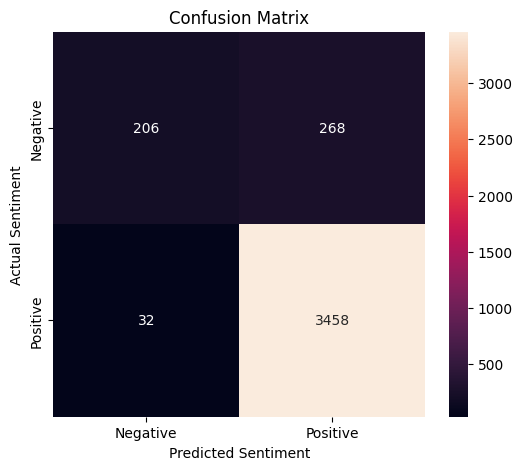

In [42]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")

plt.show()

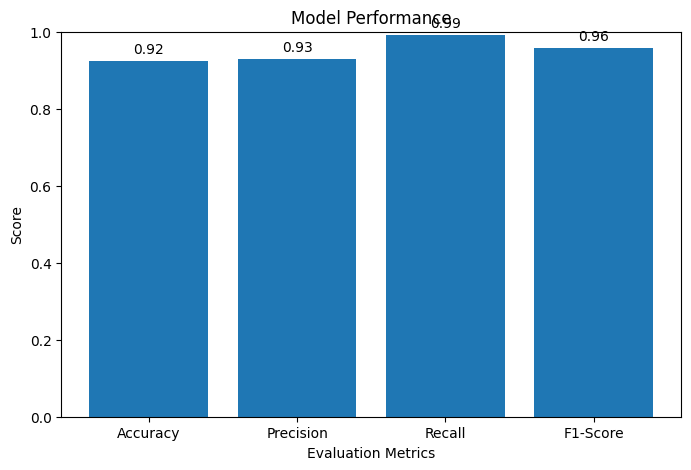

In [43]:
metrics = [accuracy, precision, recall, f1]

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

plt.figure(figsize=(8, 5))

plt.bar(metric_names, metrics)

plt.ylim(0, 1)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

plt.title("Model Performance")

for i, value in enumerate(metrics):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

## Sentiment Prediction

The trained model is tested with new product reviews to predict their sentiment and confidence.

In [44]:
def predict_sentiment(review):

    # Preprocess the new review
    cleaned_review = preprocess_text(review)

    # Convert the review into TF-IDF features
    review_tfidf = tfidf.transform([cleaned_review])

    # Predict sentiment
    prediction = model.predict(review_tfidf)[0]

    # Get prediction probabilities
    probability = model.predict_proba(review_tfidf)[0]

    # Convert numeric prediction to sentiment
    if prediction == 1:
        sentiment = "Positive"
        confidence = probability[1]
    else:
        sentiment = "Negative"
        confidence = probability[0]

    return sentiment, confidence

In [45]:
review = "I absolutely love this dress. The material is excellent and it fits perfectly."

sentiment, confidence = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", sentiment)
print(f"Confidence: {confidence * 100:.2f}%")

Review: I absolutely love this dress. The material is excellent and it fits perfectly.
Predicted Sentiment: Positive
Confidence: 99.24%


In [46]:
review = "I am very disappointed with this product. The quality is poor and I do not like it."

sentiment, confidence = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", sentiment)
print(f"Confidence: {confidence * 100:.2f}%")

Review: I am very disappointed with this product. The quality is poor and I do not like it.
Predicted Sentiment: Negative
Confidence: 98.95%


In [47]:
while True:

    review = input("\nEnter a product review (type 'exit' to stop): ")

    if review.lower() == "exit":
        print("Program ended.")
        break

    if review.strip() == "":
        print("Please enter a review.")
        continue

    sentiment, confidence = predict_sentiment(review)

    print("\nPredicted Sentiment:", sentiment)
    print(f"Confidence: {confidence * 100:.2f}%")


Enter a product review (type 'exit' to stop): This dress is beautiful and very comfortable.

Predicted Sentiment: Positive
Confidence: 97.67%

Enter a product review (type 'exit' to stop): exit
Program ended.


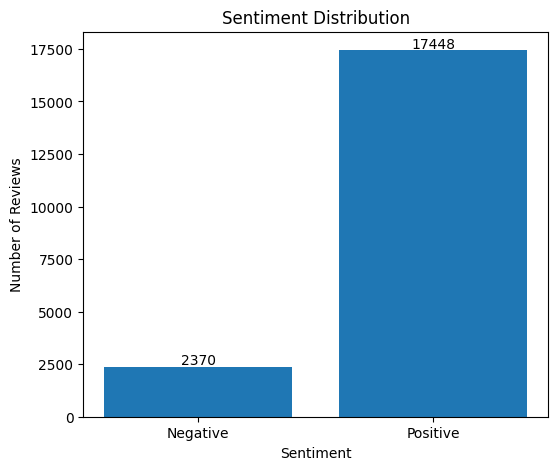

In [48]:


sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    ["Negative", "Positive"],
    [
        sentiment_counts.get(0, 0),
        sentiment_counts.get(1, 0)
    ]
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution")

for i, value in enumerate([
    sentiment_counts.get(0, 0),
    sentiment_counts.get(1, 0)
]):
    plt.text(i, value + 100, str(value), ha="center")

plt.show()

## Save the Model

The trained Logistic Regression model and TF-IDF vectorizer are saved for future use.

In [49]:
joblib.dump(model, "sentiment_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [50]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF vectorizer saved successfully!")

TF-IDF vectorizer saved successfully!


In [51]:
print("Saved files:")

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

Saved files:
tfidf_vectorizer.pkl
sentiment_model.pkl


In [52]:
df.to_csv("cleaned_product_reviews.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [53]:

files.download("sentiment_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
files.download("cleaned_product_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>